# TFG: Detección precoz de cáncer colorrectal utilizando técnicas de aprendizaje automático
**Grado en Física - Universidad Europea de Valencia**

* **Presentado por:** Gabriela Hortensia Ramos Mizrachi
* **Tutor:** Héctor Gisbert Mullor
* **Curso:** 2025-2026

---
### Resumen del Notebook
Este notebook documenta el proceso experimental que busca mejorar aspectos del algoritmo propuestos por \textcite{ripoll2025} Tomando en cuenta algunos factores

# Etapa 2: Optimización mediante aprendizaje automático: 
## Optimización de resultados anteriores

#### Primero importo todas las librerias utilizadas

In [ ]:
import re
import os
import glob
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression  # <--- Cambio aquí
from sklearn.metrics import (accuracy_score, recall_score, f1_score, 
                             roc_auc_score, confusion_matrix)

#### Configuración inicial 

In [2]:
RUTA_BASE = r"C:\Users\User\OneDrive\Documentos\TFG\Gabriela"
N_CANCER = 58   # Numero de muestras de cáncer
N_POLIPOS = 41  # Numero de muestras de pólipos
N_SANOS = 48  # Numero de muestras sanas
UMBRAL = 0.05 # Umbral de abundancia
# poner qual aqui

## Probabilidad por compuesto
Primero declaro una lista de compuesto que se excluiran de la tabla final. Defino una funcion para determinar la presencia de cancer y con ello genero una tabla de frecuencias, esta vez teniendo en cuent el CAS de cada compuesto como manera de identificación y añadiendo que la calidad del nombre tiene que ser mayor al 30%

In [3]:
ARTIFACT_PATTERNS = [
    r"SILOXANE", r"TRIMETHYLSIL", r"HEXASILOXANE", r"DODECAMETHYL",
    r"CYCLOPHANE", r"DERIVAT", r"POLYDIMETHYL", r"METACYCLOPHANE"
]

# Compilamos los patrones en uno solo para mayor eficiencia (ignorando mayúsculas/minúsculas)
PATRON_ARTEFACTOS = re.compile("|".join(ARTIFACT_PATTERNS), re.IGNORECASE)

# Diccionario para almacenar la relación Identificador -> {Nombre, CAS}
mapeo_nombres_cas = {}

def procesar_muestra(ruta_archivo, umbral):
    """
    Procesa una muestra individual. 
    Filtra por abundancia, calidad y excluye artefactos (siloxanos, etc).
    """
    try:
        df = pd.read_excel(ruta_archivo, header=None)
        
        # Localizar el inicio de los datos (marcador "1=")
        indices_marcadores = df[df.eq("1=").any(axis=1)].index.tolist()
        if len(indices_marcadores) >= 3:
            idx_inicio = indices_marcadores[2]
        elif len(indices_marcadores) > 0:
            idx_inicio = indices_marcadores[0]
        else:
            return set()
        
        data = df.iloc[idx_inicio:].copy()
        
        # Convertir a numérico para filtrar
        data[3] = pd.to_numeric(data[3], errors='coerce') # Abundancia
        data[7] = pd.to_numeric(data[7], errors='coerce') # Qual
        
        # Filtro: Abundancia >= umbral Y Calidad > 30
        filtro = (data[3] >= umbral) & (data[7] > 30)
        subset = data[filtro]
        
        presentes_en_muestra = set()
        
        for _, row in subset.iterrows():
            cas_leido = str(row[6]).strip() if pd.notna(row[6]) else ""
            nombre_completo = str(row[4]).strip() if pd.notna(row[4]) else ""

            if PATRON_ARTEFACTOS.search(nombre_completo):
                continue

            if cas_leido in ["000000-00-0", "", "nan", "0000-00-0"]:
                if nombre_completo and not nombre_completo.replace('.','',1).isdigit():
                    id_unico = nombre_completo
                    cas_final = "000000-00-0"
                else:
                    continue
            else:
                id_unico = cas_leido
                cas_final = cas_leido
            
            presentes_en_muestra.add(id_unico)
            
            # Guardar el mapeo para la tabla final
            if id_unico not in mapeo_nombres_cas:
                nombre_corto = nombre_completo.split(" $$ ")[0]
                mapeo_nombres_cas[id_unico] = {
                    "Nombre": nombre_corto,
                    "CAS": cas_final
                }
                
        return presentes_en_muestra
    except Exception:
        return set()

def ejecutar_estudio():
    grupos_config = {
        "CANCER": {"carpeta": "ENFERMOS", "pre": "M", "n": N_CANCER},
        "POLIPO": {"carpeta": "POLIPOS", "pre": "P", "n": N_POLIPOS},
        "SANO": {"carpeta": "SANOS", "pre": "S", "n": N_SANOS}
    }
    
    # Recolección de datos
    resultados = {g: [] for g in grupos_config}
    for g, info in grupos_config.items():
        dir_path = os.path.join(RUTA_BASE, info["carpeta"])
        for i in range(1, info["n"] + 1):
            file_path = os.path.join(dir_path, f"{info['pre']} ({i}).xlsx")
            if os.path.exists(file_path):
                resultados[g].append(procesar_muestra(file_path, UMBRAL))

    # Unión de todos los identificadores únicos
    todos_compuestos = set().union(*[s for lista in resultados.values() for s in lista])
    
    tabla_final = []
    for id_comp in todos_compuestos:
        pc = int(round((sum(1 for m in resultados["CANCER"] if id_comp in m) / N_CANCER) * 100)) if N_CANCER > 0 else 0
        ps = int(round((sum(1 for m in resultados["SANO"] if id_comp in m) / N_SANOS) * 100)) if N_SANOS > 0 else 0
        pp = int(round((sum(1 for m in resultados["POLIPO"] if id_comp in m) / N_POLIPOS) * 100)) if N_POLIPOS > 0 else 0
        
        # Filtro de diferencia absoluta > 10% entre Cáncer y Sanos
        if abs(ps - pc) > 10:
            info = mapeo_nombres_cas.get(id_comp, {"Nombre": id_comp, "CAS": "N/A"})
            tabla_final.append({
                "Nombre": info["Nombre"],
                "CAS": info["CAS"],
                "Prob. Enfermos (%)": pc,
                "Prob. Sanos (%)": ps,
                "Prob. Polipos (%)": pp,
                "Diff_ABS": abs(pc - ps)
            })

    df_res = pd.DataFrame(tabla_final)
    if not df_res.empty:
        df_res = df_res.sort_values(by="Diff_ABS", ascending=False).drop(columns=["Diff_ABS"])
    
    return df_res

if __name__ == "__main__":
    df_resultado = ejecutar_estudio()
    if not df_resultado.empty:
        print(df_resultado.to_string(index=False))
        # df_resultado.to_excel("resultado_filtrado_sin_artefactos.xlsx", index=False)
    else:
        print("No se encontraron compuestos que cumplan los criterios.")

                                                                          Nombre         CAS  Prob. Enfermos (%)  Prob. Sanos (%)  Prob. Polipos (%)
                                                                 1H-Indole (CAS) 000120-72-9                  45               19                 39
                                                               Triacontane (CAS) 000638-68-6                  26                8                 17
                                                             Hexanoic acid (CAS) 000142-62-1                  17               35                 32
                                                       Disulfide, dimethyl (CAS) 000624-92-0                  29               12                 12
                                                1H-Isoindole-1,3(2H)-dione (CAS) 000085-41-6                  16                0                  7
                                                                    benzaldehyde 000100-52-7              

## Cálculo de índices de Similitud: frecuencia de pacientes en funcion de Beta
Vuelvo a plotear los histogramas teniendo en cuenta los cambios anteriores

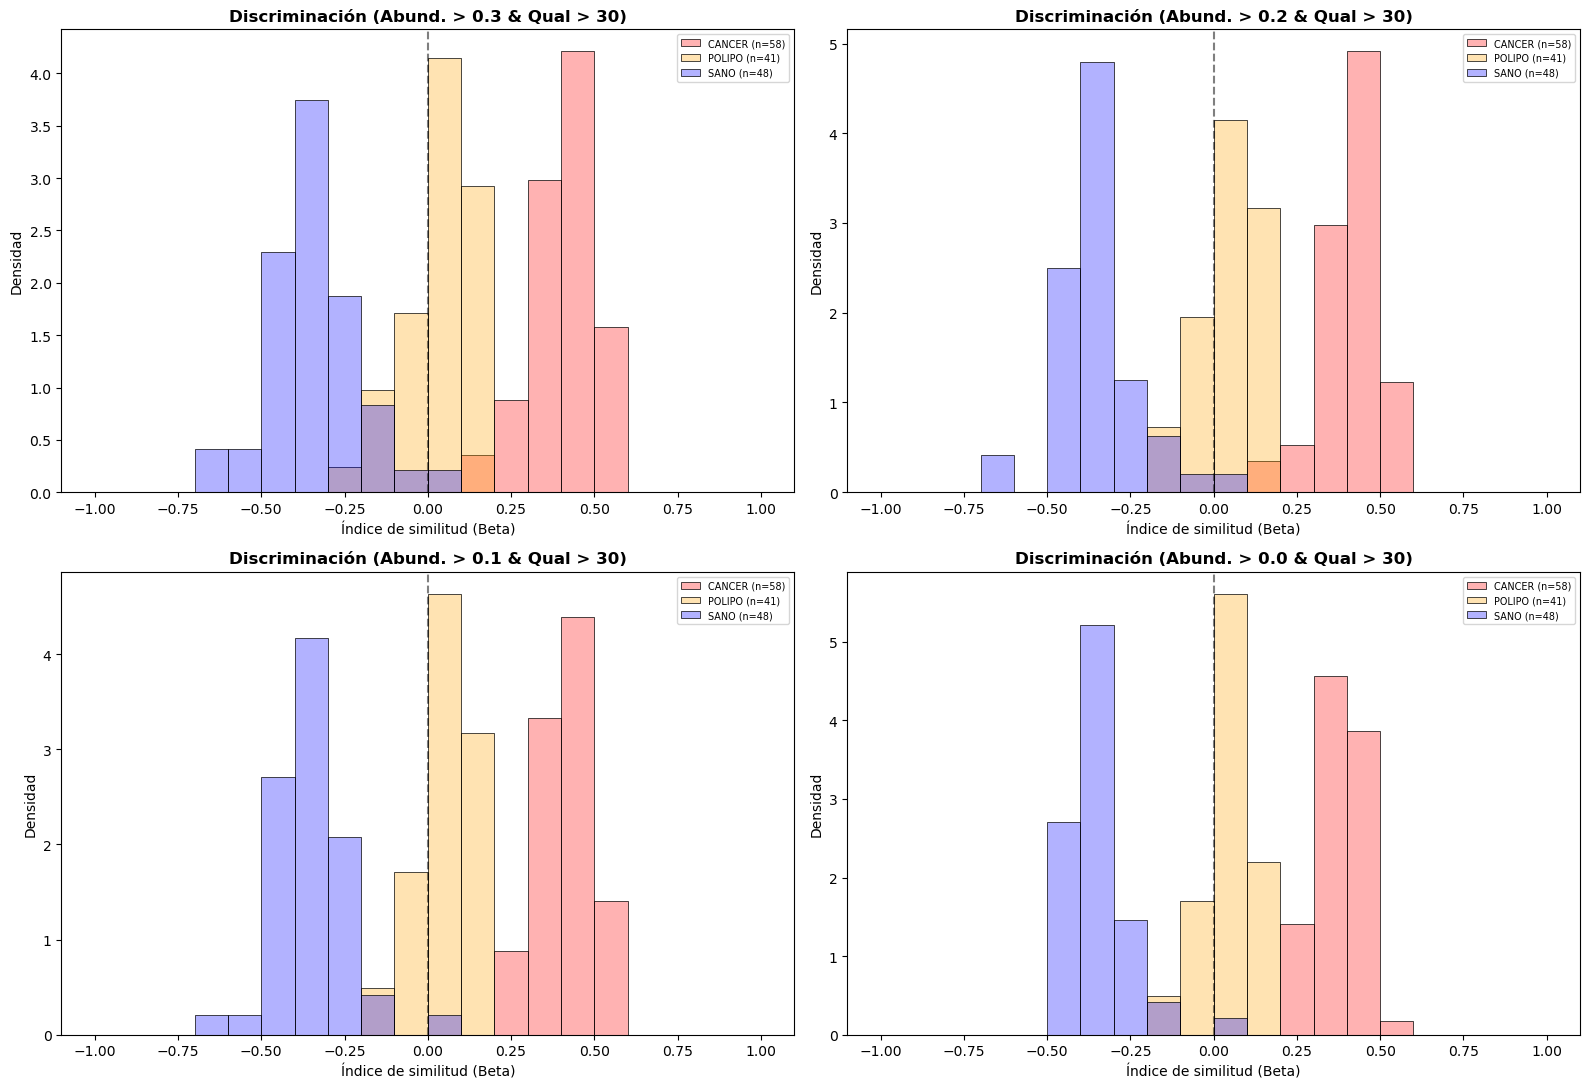

In [7]:
def presencia_cancer(file_path, umbral_abundancia=0.05, umbral_calidad=30):
    """
    Usa CAS como ID principal; si es '000000-00-0', usa el nombre.
    """
    try:
        df = pd.read_excel(file_path, header=None)
        
        # Localizar inicio de tabla (marcador "1=")
        indices_marcadores = df[df.eq("1=").any(axis=1)].index.tolist()
        if len(indices_marcadores) >= 3:
            idx_inicio = indices_marcadores[2]
        elif len(indices_marcadores) > 0:
            idx_inicio = indices_marcadores[0]
        else:
            return []
        
        data_table = df.iloc[idx_inicio:].copy()
        
        # Columnas: 3: Abundancia, 4: Nombre, 6: CAS, 7: Qual
        data_table[3] = pd.to_numeric(data_table[3], errors='coerce')
        data_table[7] = pd.to_numeric(data_table[7], errors='coerce')
        
        # Filtro de abundancia y calidad
        mask = (data_table[3] >= umbral_abundancia) & (data_table[7] > umbral_calidad)
        subset = data_table[mask]
        
        identificadores_validos = []
        for _, row in subset.iterrows():
            cas = str(row[6]).strip() if pd.notna(row[6]) else ""
            nombre = str(row[4]).strip() if pd.notna(row[4]) else ""
            
            if cas in ["000000-00-0", "", "nan", "0000-00-0"]:
                if nombre and not nombre.replace('.','',1).isdigit():
                    # Nombre corto antes del $$
                    identificadores_validos.append(nombre.split(" $$ ")[0])
            else:
                identificadores_validos.append(cas)
                
        return identificadores_validos

    except Exception as e:
        print(f"Error procesando {os.path.basename(file_path)}: {e}")
        return []

def obtener_muestras_por_umbral(umbral):
    GRUPOS = {
        "CANCER": {"carpeta": "ENFERMOS", "pre": "M", "n": N_CANCER},
        "POLIPO": {"carpeta": "POLIPOS", "pre": "P", "n": N_POLIPOS},
        "SANO": {"carpeta": "SANOS", "pre": "S", "n": N_SANOS}
    }
    
    muestras_temp = {g: [] for g in GRUPOS}
    for g, info in GRUPOS.items():
        dir_path = os.path.join(RUTA_BASE, info["carpeta"])
        for i in range(1, info["n"] + 1):
            file_path = os.path.join(dir_path, f"{info['pre']} ({i}).xlsx")
            if os.path.exists(file_path):
                resultado = presencia_cancer(file_path, umbral)
                muestras_temp[g].append(resultado)
    return muestras_temp

def graficar_discriminacion(lista_umbrales):
    fig, axes = plt.subplots(2, 2, figsize=(16, 11))
    axes = axes.flatten()
    bins_fijos = np.arange(-1.0, 1.1, 0.1)

    for i, p in enumerate(lista_umbrales):
        muestras = obtener_muestras_por_umbral(p)
    
        picos_ref = set().union(*[s for g in ["CANCER", "SANO"] for s in muestras[g]])
        
        pesos = {}
        for pico in picos_ref:
            pc = sum(1 for s in muestras["CANCER"] if pico in s) / max(len(muestras["CANCER"]), 1)
            ps = sum(1 for s in muestras["SANO"] if pico in s) / max(len(muestras["SANO"]), 1)
            pesos[pico] = (pc - ps) / (pc + ps) if (pc + ps) > 0 else 0

        ax = axes[i]
        for g in ["CANCER", "POLIPO", "SANO"]:
            # Índice Beta promedio por paciente
            betas = [np.mean([pesos.get(comp, 0) for comp in s]) if s else 0 for s in muestras[g]]
            
            # Histograma 
            sns.histplot(betas, bins=bins_fijos, color=COLORES[g], alpha=0.3, 
                         label=f"{g} (n={len(betas)})", ax=ax, stat="density", 
                         edgecolor='black', linewidth=0.5, kde=False) 
        
        ax.set_title(f"Discriminación (Abund. > {p} & Qual > 30)", fontweight='bold')
        ax.set_xlim(-1.1, 1.1)
        ax.axvline(0, color='black', linestyle='--', alpha=0.5)
        ax.set_xlabel("Índice de similitud (Beta)")
        ax.set_ylabel("Densidad")
        ax.legend(fontsize='x-small')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    graficar_discriminacion([0.3, 0.2, 0.1, 0.0])

## Validación

Saco metricas para comparar con los distintos modelos

In [ ]:
UMBRAL_ABUNDANCIA = 0.05
UMBRAL_CALIDAD = 30
N_CICLOS = 20
TEST_SIZE = 0.20

GRUPOS_CONFIG = {
    "CANCER": {"carpeta": "ENFERMOS", "pre": "M", "n": 58, "label": 1},
    "SANO": {"carpeta": "SANOS", "pre": "S", "n": 48, "label": 0},
}

# ==========================================
# FUNCIONES DE PROCESAMIENTO
# ==========================================
def procesar_archivo(ruta_archivo):
    try:
        df = pd.read_excel(ruta_archivo, header=None)
        indices = df[df.eq("1=").any(axis=1)].index.tolist()
        idx_inicio = indices[2] if len(indices) >= 3 else (indices[0] if indices else None)
        
        if idx_inicio is None: return set()

        data = df.iloc[idx_inicio:].copy()
        data[3] = pd.to_numeric(data[3], errors='coerce')
        data[7] = pd.to_numeric(data[7], errors='coerce')
        
        filtro = (data[3] >= UMBRAL_ABUNDANCIA) & (data[7] > UMBRAL_CALIDAD)
        subset = data[filtro]
        
        presentes = set()
        for _, row in subset.iterrows():
            nombre_completo = str(row[4]).strip() if pd.notna(row[4]) else ""
            cas_leido = str(row[6]).strip() if pd.notna(row[6]) else ""

            if PATRON_ARTEFACTOS.search(nombre_completo):
                continue

            if cas_leido in ["000000-00-0", "", "nan", "0000-00-0"]:
                if nombre_completo and not nombre_completo.replace('.','',1).isdigit():
                    id_unico = nombre_completo.split(" $$ ")[0]
                else: continue
            else:
                id_unico = cas_leido
            
            presentes.add(id_unico)
        return presentes
    except Exception:
        return set()

# ==========================================
# CONSTRUCCIÓN DEL DATASET
# ==========================================
muestras_data = []
etiquetas = []
todos_los_compuestos = set()

for grupo, info in GRUPOS_CONFIG.items():
    dir_path = os.path.join(RUTA_BASE, info["carpeta"])
    for i in range(1, info["n"] + 1):
        file_path = os.path.join(dir_path, f"{info['pre']} ({i}).xlsx")
        if os.path.exists(file_path):
            compuestos = procesar_archivo(file_path)
            if compuestos:
                muestras_data.append(compuestos)
                etiquetas.append(info["label"])
                todos_los_compuestos.update(compuestos)

compuestos_lista = sorted(list(todos_los_compuestos))
X = []
for m in muestras_data:
    fila = [1 if c in m else 0 for c in compuestos_lista]
    X.append(fila)

X = np.array(X)
y = np.array(etiquetas)

# ENTRENAMIENTO Y CICLOS
metricas = {
    "accuracy": [], 
    "recall": [], 
    "precision": [],
    "sensibilidad": [], 
    "especificidad": [],
    "auc": [], 
    "f1": []
}

for i in range(N_CICLOS):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, stratify=y, random_state=i
    )
    
    modelo = LogisticRegression(max_iter=1000, random_state=i)
    modelo.fit(X_train, y_train)
    
    y_pred = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]
    
    # Cálculo de métricas manuales (Especificidad)
    cm = confusion_matrix(y_test, y_pred)
    if cm.size == 4:
        tn, fp, fn, tp = cm.ravel()
        especificidad = tn / (tn + fp) if (tn + fp) > 0 else 0
    else:
        especificidad = 0
    
    # Guardar métricas
    metricas["accuracy"].append(accuracy_score(y_test, y_pred))
    
    # Recall y Sensibilidad son lo mismo, se calculan igual:
    rec = recall_score(y_test, y_pred, zero_division=0)
    metricas["recall"].append(rec)
    metricas["sensibilidad"].append(rec)
    
    metricas["precision"].append(precision_score(y_test, y_pred, zero_division=0))
    metricas["especificidad"].append(especificidad)
    metricas["f1"].append(f1_score(y_test, y_pred, zero_division=0))
    metricas["auc"].append(roc_auc_score(y_test, y_proba))

# RESULTADOS FINALES

print(f"MÉTRICAS: MEDIANA (± DESV. EST.) - {N_CICLOS} CICLOS")

for m, valores in metricas.items():
    mediana = np.median(valores)
    desv_est = np.std(valores)
    # Formateo para que la columna de nombres se vea ordenada
    print(f"{m.capitalize():15}: {mediana:.4f} (±{desv_est:.4f})")


MÉTRICAS: MEDIANA (± DESV. EST.) - 20 CICLOS
Accuracy       : 0.6667 (±0.0871)
Recall         : 0.8333 (±0.0890)
Precision      : 0.6905 (±0.0711)
Sensibilidad   : 0.8333 (±0.0890)
Especificidad  : 0.5000 (±0.1502)
Auc            : 0.7361 (±0.0990)
F1             : 0.7275 (±0.0671)
